In [40]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, precision_score, recall_score, f1_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import sklearn.linear_model as lm
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

In [21]:
df = pd.read_csv("Phishing dataset.csv")

In [22]:
print(f"data head:\n {df.sample(3)}")
print(f"data information:\n {df.info(3)}")
print(f"data about:\n {df.describe()}")
print(f"data having columns:\n {df.columns}")

data head:
                 Domain  Have_IP  Have_At  URL_Length  URL_Depth  Redirection  \
7794  ch.prunauneau.fr        0        0           0          1            0   
7421        fareast.qa        0        0           1          3            0   
4038       twitter.com        0        0           1          1            0   

      https_Domain  TinyURL  Prefix/Suffix  DNS_Record  Web_Traffic  \
7794             0        0              0           0            1   
7421             0        0              0           1            1   
4038             0        0              0           0            1   

      Domain_Age  Domain_End  iFrame  Mouse_Over  Right_Click  Web_Forwards  \
7794           0           1       0           0            1             0   
7421           1           1       1           0            1             0   
4038           1           1       0           0            1             0   

      Label  
7794      1  
7421      1  
4038      0  
<class 'p

In [23]:
df.isnull().sum()

Domain           0
Have_IP          0
Have_At          0
URL_Length       0
URL_Depth        0
Redirection      0
https_Domain     0
TinyURL          0
Prefix/Suffix    0
DNS_Record       0
Web_Traffic      0
Domain_Age       0
Domain_End       0
iFrame           0
Mouse_Over       0
Right_Click      0
Web_Forwards     0
Label            0
dtype: int64

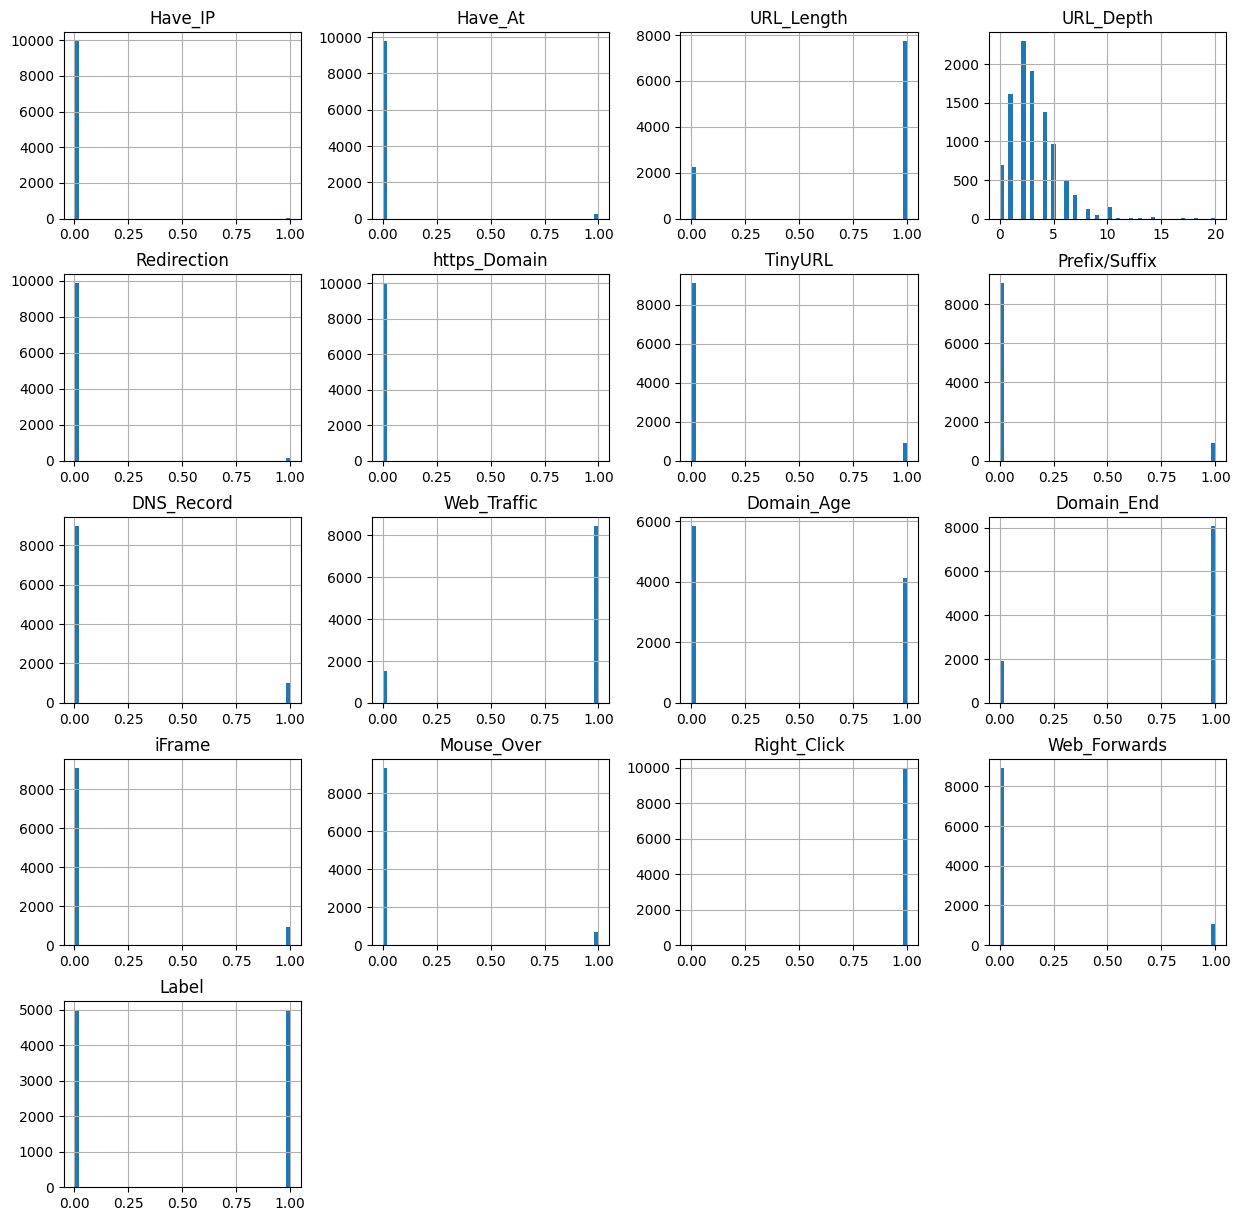

In [24]:
df.hist(bins=50,figsize=(15,15))
plt.show()

In [25]:
df = df.drop(['Domain'],axis=1).copy()

<Axes: >

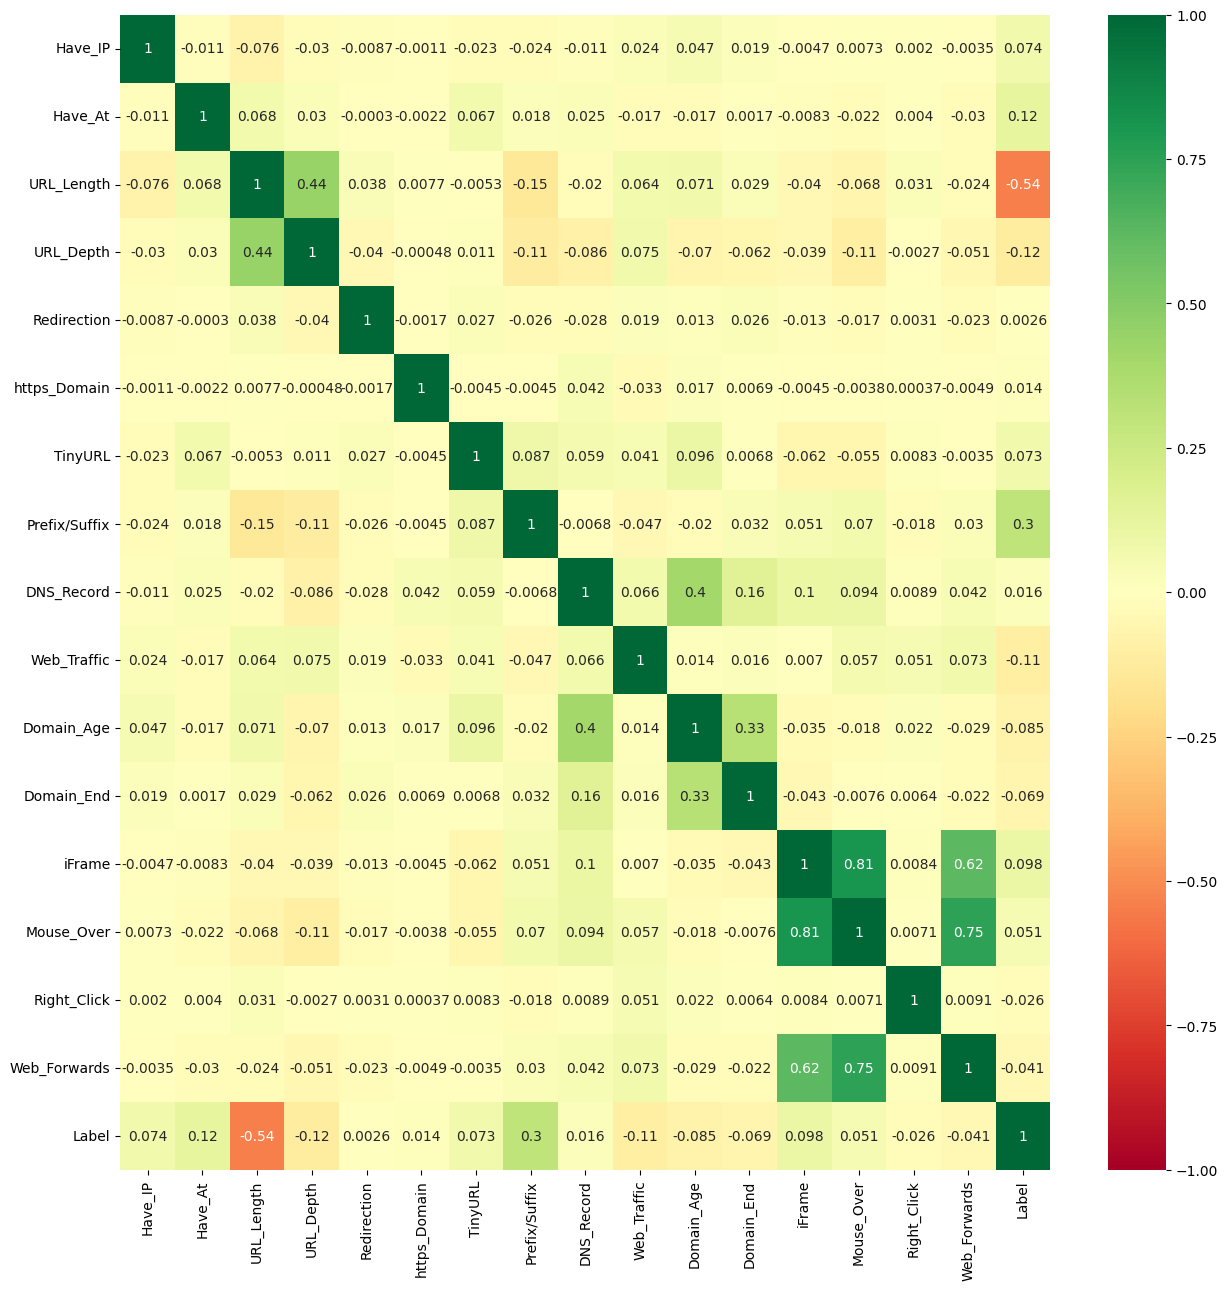

In [26]:
plt.figure(figsize=(15,15))
sns.heatmap(
    df.corr(),
    cmap='RdYlGn',
    vmin=-1,
    vmax=1,
    annot=True
)

In [27]:
df.columns

Index(['Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Redirection',
       'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic',
       'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Right_Click',
       'Web_Forwards', 'Label'],
      dtype='object')

In [28]:
y = df['Label']
X = df.drop(['Label'], axis=1)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42)

In [42]:
ML_Model = []
acc_train = []
acc_test = []

#function to call for storing the results
def storeResults(model, a,b):
  ML_Model.append(model)
  acc_train.append(round(a, 3))
  acc_test.append(round(b, 3))

In [44]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train,np.ravel(y_train,order='C'))
y_predict= model.predict(X_test)
y_train_model = model.predict(X_train)
y_test_model = model.predict(X_test)
model_score=model.score(X_test, y_test)

In [45]:
acc_train_model = accuracy_score(y_train,y_train_model)
acc_test_model = accuracy_score(y_test,y_test_model)

print("LogisticRegression: Accuracy on the Model: ",model_score)
print("LogisticRegression: Accuracy on training Data: {:.3f}".format(acc_train_model))
print("LogisticRegression: Accuracy on test Data: {:.3f}".format(acc_test_model))
print(metrics.classification_report(y_test, y_predict))
print(metrics.confusion_matrix(y_test, y_predict))

LogisticRegression: Accuracy on the Model:  0.7925
LogisticRegression: Accuracy on training Data: 0.807
LogisticRegression: Accuracy on test Data: 0.792
              precision    recall  f1-score   support

           0       0.73      0.94      0.82      1012
           1       0.92      0.64      0.75       988

    accuracy                           0.79      2000
   macro avg       0.82      0.79      0.79      2000
weighted avg       0.82      0.79      0.79      2000

[[955  57]
 [358 630]]


In [46]:
storeResults('LogisticRegression', acc_train_model, acc_test_model)

In [47]:
tree = DecisionTreeClassifier(max_depth = 5)
tree.fit(X_train, y_train)
y_test_tree = tree.predict(X_test)
y_train_tree = tree.predict(X_train)

tree_score=model.score(X_test, y_test)

In [48]:
acc_train_tree = accuracy_score(y_train,y_train_tree)
acc_test_tree = accuracy_score(y_test,y_test_tree)

print("Decision Tree: Accuracy on the Model: ",tree_score)
print("Decision Tree: Accuracy on training Data: {:.3f}".format(acc_train_tree))
print("Decision Tree: Accuracy on test Data: {:.3f}".format(acc_test_tree))
print(metrics.classification_report(y_test, y_predict))
print(metrics.confusion_matrix(y_test, y_predict))

Decision Tree: Accuracy on the Model:  0.7925
Decision Tree: Accuracy on training Data: 0.815
Decision Tree: Accuracy on test Data: 0.806
              precision    recall  f1-score   support

           0       0.73      0.94      0.82      1012
           1       0.92      0.64      0.75       988

    accuracy                           0.79      2000
   macro avg       0.82      0.79      0.79      2000
weighted avg       0.82      0.79      0.79      2000

[[955  57]
 [358 630]]


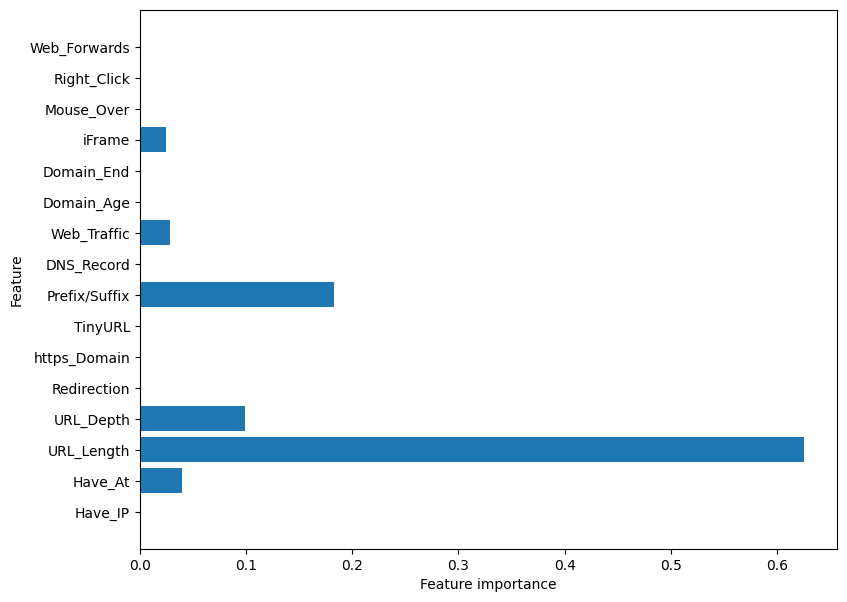

In [49]:
plt.figure(figsize=(9,7))
n_features = X_train.shape[1]
plt.barh(range(n_features), tree.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

In [50]:
storeResults('Decision Tree', acc_train_tree, acc_test_tree)

In [51]:
forest = RandomForestClassifier(max_depth=5)
forest.fit(X_train, y_train)
y_test_forest = forest.predict(X_test)
y_train_forest = forest.predict(X_train)
model_score=model.score(X_test, y_test)

In [52]:
acc_train_forest = accuracy_score(y_train,y_train_forest)
acc_test_forest = accuracy_score(y_test,y_test_forest)

print("Random forest: Accuracy on the Model: ",model_score)
print("Random forest: Accuracy on training Data: {:.3f}".format(acc_train_forest))
print("Random forest: Accuracy on test Data: {:.3f}".format(acc_test_forest))
print(metrics.classification_report(y_test, y_predict))
print(metrics.confusion_matrix(y_test, y_predict))

Random forest: Accuracy on the Model:  0.7925
Random forest: Accuracy on training Data: 0.821
Random forest: Accuracy on test Data: 0.812
              precision    recall  f1-score   support

           0       0.73      0.94      0.82      1012
           1       0.92      0.64      0.75       988

    accuracy                           0.79      2000
   macro avg       0.82      0.79      0.79      2000
weighted avg       0.82      0.79      0.79      2000

[[955  57]
 [358 630]]


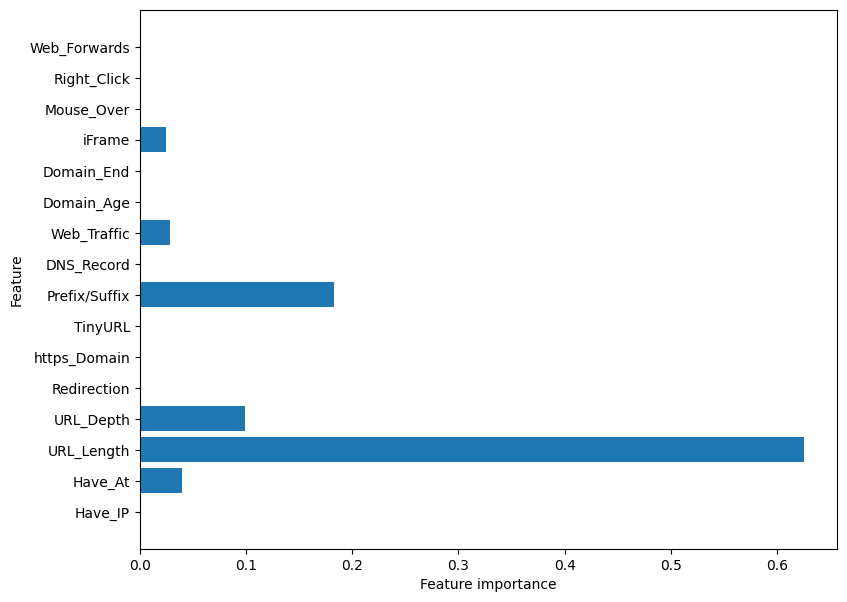

In [53]:
plt.figure(figsize=(9,7))
n_features = X_train.shape[1]
plt.barh(range(n_features), tree.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

In [54]:
storeResults('Random forest', acc_train_forest, acc_test_forest)

In [55]:
knn = KNeighborsClassifier(n_neighbors =1)
knn.fit(X_train,np.ravel(y_train,order='C'))
y_predict= knn.predict(X_test)

y_test_knn = knn.predict(X_test)
y_train_knn = knn.predict(X_train)
model_score=knn.score(X_test, y_test)

In [56]:
acc_train_knn = accuracy_score(y_train,y_train_knn)
acc_test_knn = accuracy_score(y_test,y_test_knn)

print("KNeighborsClassifier: Accuracy on the Model: ",model_score)
print("KNeighborsClassifier: Accuracy on training Data: {:.3f}".format(acc_train_knn))
print("KNeighborsClassifier: Accuracy on test Data: {:.3f}".format(acc_test_knn))
print(metrics.classification_report(y_test, y_predict))
print(metrics.confusion_matrix(y_test, y_predict))

KNeighborsClassifier: Accuracy on the Model:  0.7895
KNeighborsClassifier: Accuracy on training Data: 0.814
KNeighborsClassifier: Accuracy on test Data: 0.789
              precision    recall  f1-score   support

           0       0.78      0.81      0.80      1012
           1       0.80      0.77      0.78       988

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000

[[818 194]
 [227 761]]


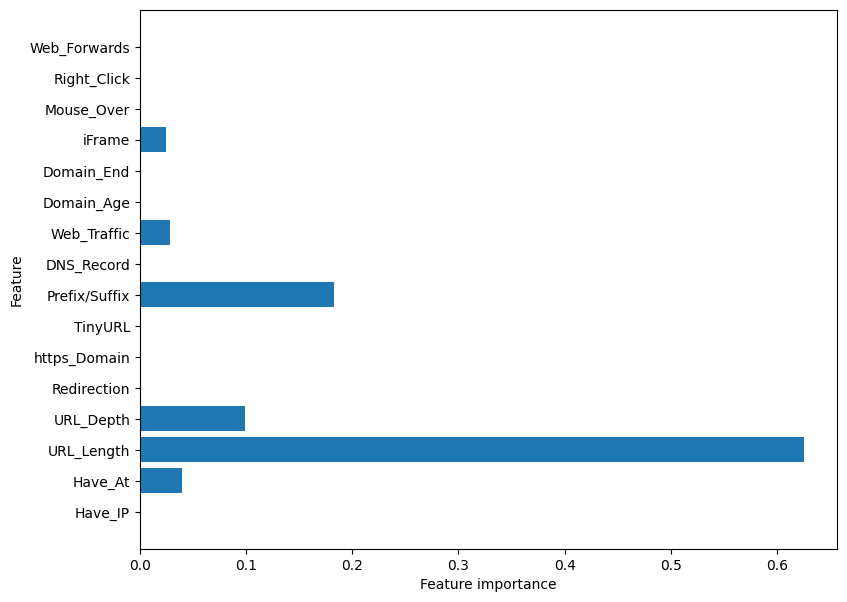

In [57]:
plt.figure(figsize=(9,7))
n_features = X_train.shape[1]
plt.barh(range(n_features), tree.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

In [58]:
storeResults('KNeighborsClassifier', acc_train_knn, acc_test_knn)

In [59]:
xgb = XGBClassifier(use_label_encoder =False,learning_rate=0.4,max_depth=7)
xgb.fit(X_train, y_train)
y_test_xgb = xgb.predict(X_test)
y_train_xgb = xgb.predict(X_train)
model_score=xgb.score(X_test, y_test)

c:\Users\admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:03:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [60]:
acc_train_xgb = accuracy_score(y_train,y_train_xgb)
acc_test_xgb = accuracy_score(y_test,y_test_xgb)

print("XGBoost: Accuracy on the Model: ",model_score)
print("XGBoost: Accuracy on training Data: {:.3f}".format(acc_train_xgb))
print("XGBoost : Accuracy on test Data: {:.3f}".format(acc_test_xgb))
print(metrics.classification_report(y_test, y_predict))
print(metrics.confusion_matrix(y_test, y_predict))

XGBoost: Accuracy on the Model:  0.856
XGBoost: Accuracy on training Data: 0.868
XGBoost : Accuracy on test Data: 0.856
              precision    recall  f1-score   support

           0       0.78      0.81      0.80      1012
           1       0.80      0.77      0.78       988

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000

[[818 194]
 [227 761]]


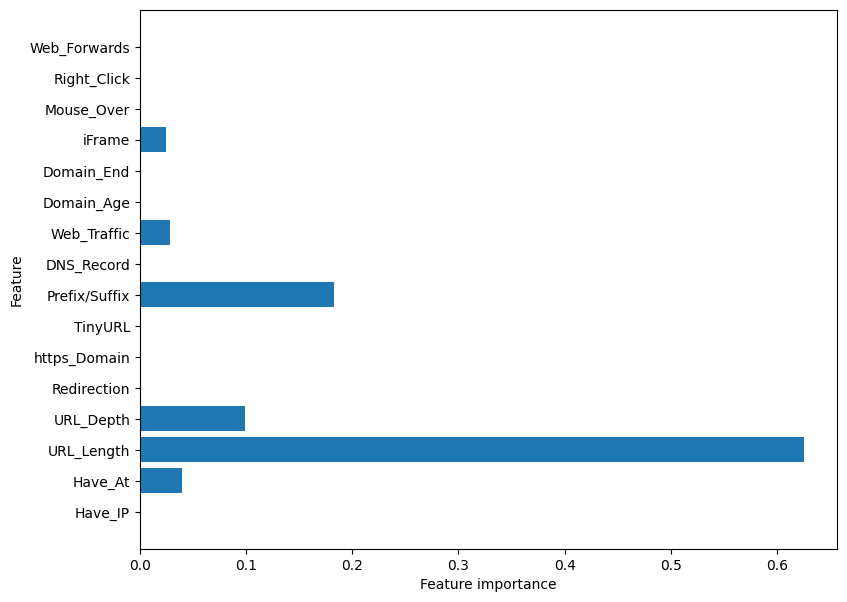

In [61]:
plt.figure(figsize=(9,7))
n_features = X_train.shape[1]
plt.barh(range(n_features), tree.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

In [62]:
storeResults('XGBoost', acc_train_xgb, acc_test_xgb)

In [63]:
results = pd.DataFrame({ 'ML Model': ML_Model,
    'Train Accuracy': acc_train,
    'Test Accuracy': acc_test})
results

,ML Model,Train Accuracy,Test Accuracy
0,LogisticRegression,0.807,0.792
1,Decision Tree,0.815,0.806
2,Random forest,0.821,0.812
3,KNeighborsClassifier,0.814,0.789
4,XGBoost,0.868,0.856


In [64]:
results.sort_values(by=['Test Accuracy', 'Train Accuracy'], ascending=False)

,ML Model,Train Accuracy,Test Accuracy
4,XGBoost,0.868,0.856
2,Random forest,0.821,0.812
1,Decision Tree,0.815,0.806
0,LogisticRegression,0.807,0.792
3,KNeighborsClassifier,0.814,0.789


In [65]:
import pickle
pickle.dump(xgb, open("XGBoostClassifier.pickle.dat", "wb"))
pickle.dump(xgb, open("phishing.pkl", "wb"))

In [67]:
import pickle

# Save the model as phishing_model.pkl
with open("phishing_model.pkl", "wb") as file:
    pickle.dump(xgb, file)

print("XGBoost model saved")

XGBoost model saved


In [70]:


with open("phishing_model.pkl", "rb") as file:
    model = pickle.load(file)

sample_input = np.array([[1, 0, 1, 2, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1]])

prediction = model.predict(sample_input)

if prediction[0] == 1:
    print("This website is likely a PHISHING website")
else:
    print("This website is safe")

This website is likely a PHISHING website


In [72]:
website_name = "www.example.com"

sample_input = np.array([[1, 0, 1, 2, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1]])

with open("phishing_model.pkl", "rb") as file:
    model = pickle.load(file)

prediction = model.predict(sample_input)

if prediction[0] == 1:
    print("The website is likely a PHISHING website")
else:
    print("The website  is likely SAFE")

The website is likely a PHISHING website
